#### Series de tiempo: se tratan de un conjunto de datos históricos que representan un proceso de cambios en los valores conforme avanza el tiempo, sus principales componentes estadísticos son los siguientes

Nivel: media estadística de la serie.

Tendencia: dirección general y el cambio a largo plazo del nivel de la serie.

Estacionalidad: patrones cíclicos que se repiten en intervalos regurales(diarios, semanales, anuales, etc).

Ruido: al igual que un conjunto de datos convencional, sufren de errores aleatorios e imprecisiones que no tienen un origen concreto.

In [27]:
import pandas as pd
import numpy as np
from scipy.stats import pearsonr
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf 
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import dash
import dash_core_components as dcc
import dash_html_components as html
from dash.dependencies import Output, Input


df = pd.read_csv("archivos_csv/bitcoin_usd.csv")
df["date"] = pd.to_datetime(df["date"],format='%Y-%m-%d')
df.sort_values(by="date", inplace=True)
df

,date,open_USD,high_USD,low_USD,close_USD,volume
999,2018-05-07,9661.02,9689.67,9181.00,9365.00,33787
998,2018-05-08,9365.00,9475.70,9060.54,9187.56,25533
997,2018-05-09,9178.00,9390.00,8965.00,9310.00,25673
996,2018-05-10,9310.00,9395.12,8970.00,9002.20,25055
995,2018-05-11,9002.21,9016.80,8341.00,8400.00,48227
...,...,...,...,...,...,...
4,2021-01-26,32254.19,32921.88,30837.37,32467.77,84972
3,2021-01-27,32464.01,32557.29,29241.72,30366.15,95911
2,2021-01-28,30362.19,33783.98,29842.10,33364.86,92621
1,2021-01-29,33368.18,38531.90,31915.40,34252.20,231827


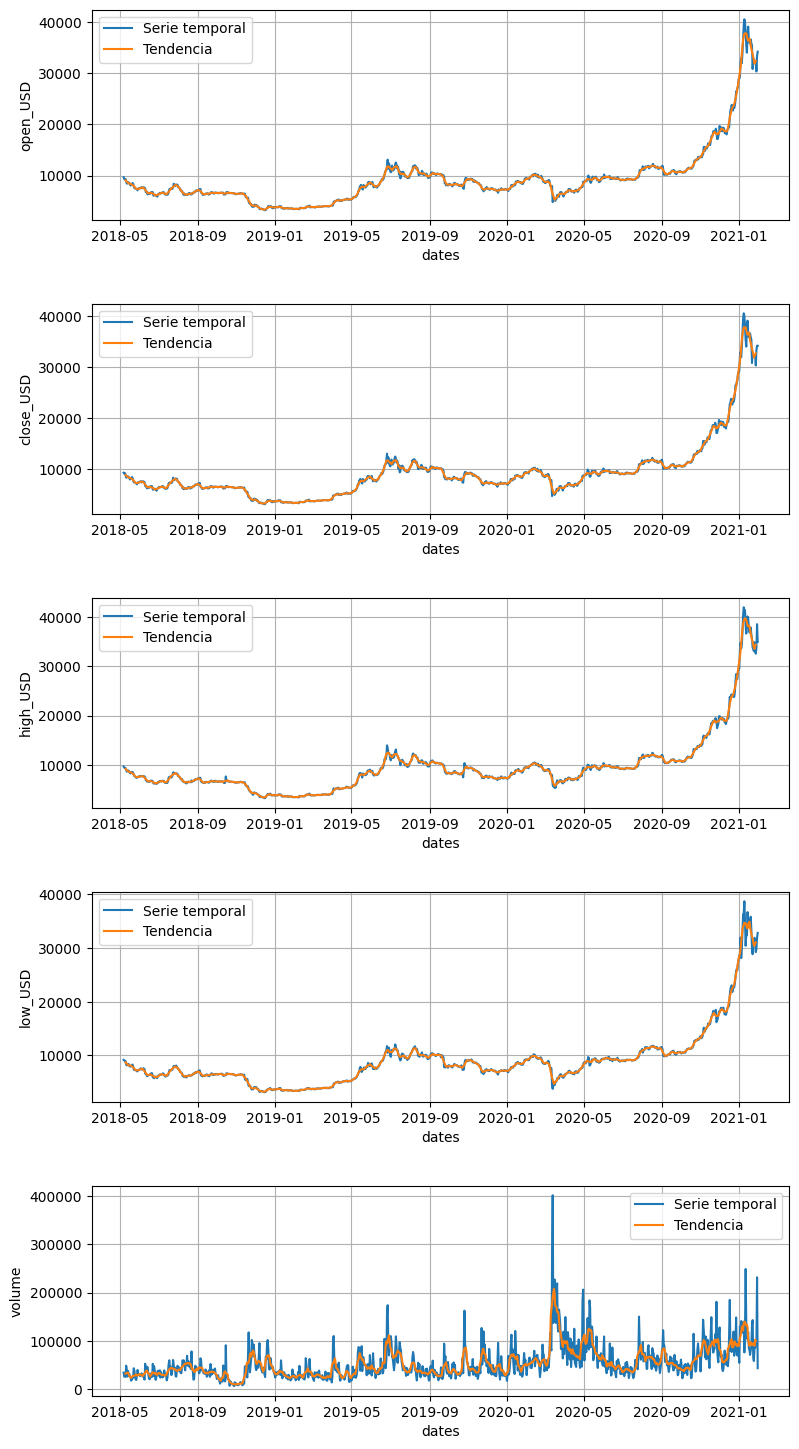

In [3]:
df.set_index("date", inplace=True)

fig, ax = plt.subplots(5,1, figsize=(9,18))

ax[0].plot(df["open_USD"], label="Serie temporal")
ax[0].plot(seasonal_decompose(df["open_USD"], model="aditive").trend, label="Tendencia")
ax[0].set_ylabel("open_USD")
ax[0].set_xlabel("dates")
ax[0].legend()
ax[0].grid("on")

ax[1].plot(df["close_USD"], label="Serie temporal")
ax[1].plot(seasonal_decompose(df["close_USD"], model="aditive").trend, label="Tendencia")
ax[1].set_ylabel("close_USD")
ax[1].set_xlabel("dates")
ax[1].legend()
ax[1].grid("on")

ax[2].plot(df["high_USD"], label="Serie temporal")
ax[2].plot(seasonal_decompose(df["high_USD"], model="aditive").trend, label="Tendencia")
ax[2].set_ylabel("high_USD")
ax[2].set_xlabel("dates")
ax[2].legend()
ax[2].grid("on")

ax[3].plot(df["low_USD"], label="Serie temporal")
ax[3].plot(seasonal_decompose(df["low_USD"], model="aditive").trend, label="Tendencia")
ax[3].set_ylabel("low_USD")
ax[3].set_xlabel("dates")
ax[3].legend()
ax[3].grid("on")

ax[4].plot(df["volume"], label="Serie temporal")
ax[4].plot(seasonal_decompose(df["volume"], model="aditive").trend, label="Tendencia")
ax[4].set_ylabel("volume")
ax[4].set_xlabel("dates")
ax[4].legend()
ax[4].grid("on")

plt.subplots_adjust(hspace=0.4)
plt.show()

### Análisis de estacionalidad 

Autocorrelación: mide la correlación lineal entre una serie de tiempo y una versión de esta con un determinado retardo, es decir, sin los valores más recientes.

Correlograma: diagrama que muestra un conjunto de autocorrelaciones con sus respectivos retardos, mediante observemos los cambios de la figura podremos estimar un patrón estacional.

In [36]:
# fig, ax = plt.subplots(5,1, figsize=(30,35))

# plot_acf(df["open_USD"], lags=df.shape[0] - 1, ax=ax[0])
# ax[0].set_title("open_USD")
# ax[0].set_ylabel("Autocorrelación")
# ax[0].set_xlabel("Retardo(K)")

# plot_acf(df["close_USD"], lags=df.shape[0] - 1, ax=ax[1])
# ax[1].set_title("close_USD")
# ax[1].set_ylabel("Autocorrelación")
# ax[1].set_xlabel("Retardo(K)")

# plot_acf(df["high_USD"], lags=df.shape[0] - 1, ax=ax[2])
# ax[2].set_title("high_USD")
# ax[2].set_ylabel("Autocorrelación")
# ax[2].set_xlabel("Retardo(K)")

# plot_acf(df["low_USD"], lags=df.shape[0] - 1, ax=ax[3])
# ax[3].set_title("low_USD")
# ax[3].set_ylabel("Autocorrelación")
# ax[3].set_xlabel("Retardo(K)")

# plot_acf(df["volume"], lags=df.shape[0] - 1, ax=ax[4])
# ax[4].set_title("volume")
# ax[4].set_ylabel("Autocorrelación")
# ax[4].set_xlabel("Retardo(K)")

# plt.subplots_adjust(wspace=0.4)
# plt.show()


def correlogram(df, column):
    autocorrelations = []
    lags = list(range(0, df.shape[0]))
    for l in lags:
        ac = pearsonr(df.loc[:l, column], df.loc[df.shape[0]-l:, column])
        autocorrelations.append(ac)
    correlogram = go.Scatter(x=lags, y=autocorrelations, mode="markers", name="ACF")
    # correlogram.add_trace(go.Scatter(x=lags[0], y=0), mode="lines", name="Umbral")
    # correlogram.add_trace(go.Scatter(x=lags[-1], y=0), mode="lines", name="Umbral")
    return correlogram

volume_correlogram = correlogram(df, "volume")
volume_correlogram

1000 1000


#### Dashboard de forecasting realizado por un modelo adecuado a la serie de tiempo

In [ ]:
df.reset_index(inplace=True)

app = dash.Dash(__name__)
app.layout =  html.Div(id="body", className="e7_body", children=[
    html.H1("Forecasting", id="title", className="e7_title"),
    dcc.Dropdown(id="dropdown", className="e7_dropdown",
                        options=[
                            {"label":"Vólumen de trading","value":"volume"},
                            {"label":"Precio de apertura","value":"open_USD"},
                            {"label":"Precio de cierre","value":"close_USD"},
                            {"label":"Precio más bajo","value":"low_USD"},
                            {"label":"Precio más alto","value":"high_USD"},

                        ],
                        value="volume",
                        multi=False,
                        clearable=False),
    dcc.Graph(id="forecasting", figure={}, className="e7_graph")
])

@app.callback(
    Output(component_id="forecasting",component_property="figure"),
    [Input(component_id="dropdown",component_property="value")]
)

def update_graph(slct_var):
    
    if slct_var == "volume":
        TES = ExponentialSmoothing(df[slct_var], seasonal="add", seasonal_periods=100)
    else:
        TES = ExponentialSmoothing(df[slct_var], trend="add", seasonal="add", seasonal_periods=300)
    
    model = TES.fit()
            
    new_dates = list(pd.date_range('2021-01-31','2021-03-01'))
    predicts = model.forecast(30)
    
    forecasting = go.Figure()
    forecasting.add_trace(go.Scatter(x=df["date"], y=df[slct_var], mode="lines", name="Serie"))
    forecasting.add_trace(go.Scatter(x=new_dates, y=predicts, mode="lines", name="Pronóstico"))
    forecasting.update_layout(title_text="Pronóstico del siguiente mes")
    forecasting.update_yaxes(title_text=slct_var)

    return forecasting

if __name__ == "__main__":
    app.run_server(debug=False)

#### Suavización Exponencial: dentro de los algoritmos de series temporales se encuentran ARIMA, SARIMA o el que se implementó en en este ejemplo, su método se basa precisamente en suavizar las fluctuaciones de la serie a través de una combinación ponderada de valores anteriores, los parámetros que utiliza son el factor de suavización(Valor Alpha) y el Nivel inicial(0). Dependiendo del comportamiento de la serie el modelo puede ir variando y añadiendo más componentes, algunos ejemplos de versiones de Suavizado Exporencial son: suavizado simple, tendencia lineal de Holt, tendencia amortiguada, estacional simple o aditivo de Winters

Suavización Exponencial Doble o Estacional Simple: modelo apropiado para series de tiempo con tendencia y un efecto estacional que es constante a lo largo del tiempo, sus parámetros de suavizado son el nivel, la tendencia y la estacionalidad, además se especifica cada cuanto es el período de tiempo en que transcurre ese patrón.